# Chapter 14: Differential Forms

**Source Span.** *Introduction to Smooth Manifolds*, Chapter 14, printed pages 349-376. I inspected roughly PDF pages 367-394 with `pdftotext -layout`, including alternating tensors, elementary alternating tensors, wedge products, differential forms, pullbacks, exterior derivatives, invariant formulas, interior multiplication, and Lie derivatives of forms.

**Chapter goal.** Make differential forms feel computational without flattening their geometry: alternating tensors measure oriented volume, wedge products assemble independent covector measurements, pullbacks move forms backward through maps, the exterior derivative raises degree and squares to zero, and Cartan's formula packages Lie differentiation into `i_V d + d i_V`.

The source is used only for structure, terminology, theorem orientation, and concept coverage. The prose, code, diagrams, and checks below are original.


## Translation Guide

| Chapter idea | Computational model | Inspection target |
| --- | --- | --- |
| Alternating tensor | determinant-style multilinear rule | repeated or dependent inputs produce zero |
| Elementary `k`-covectors | selected minors of a component matrix | basis count is `binomial(n,k)` |
| Wedge product | antisymmetrized tensor product | area/volume changes sign when arguments swap |
| Differential form | smoothly varying alternating tensor | coefficient functions live in charts, but pullbacks are invariant |
| Exterior derivative | coefficient derivatives arranged with signs | `d(d f)=0`, product rule, pullback commutation |
| Interior multiplication | insert a vector field into first slot | degree drops by one with a sign rule |
| Cartan formula | `L_V omega = i_V d omega + d(i_V omega)` | flow change agrees with exterior calculus |


## Planner Pass: Visual Storyboard and Library Routing

| Storyboard item | Representation | Library route | Artifact target | Validation target |
| --- | --- | --- | --- | --- |
| Proof dependency map | directed graph from alternating algebra to Cartan formula | NetworkX + Matplotlib | `figures/forms-concept-dependency.png` | graph reaches exterior derivative and Cartan formula |
| Alternating basis count | dimension table and determinant minors | SymPy, CSV, Matplotlib | `figures/alternating-basis-counts.png` | `dim Lambda^k(R^n*) = binomial(n,k)` |
| Wedge product geometry | oriented parallelogram and sign reversal | Matplotlib, NumPy | `figures/wedge-product-oriented-area.png` | swapped arguments negate area |
| Pullback of forms | coordinate substitution diagram | SymPy, Matplotlib | `figures/pullback-commutes-with-exterior-derivative.png` | `F^*(d omega)=d(F^* omega)` |
| Exterior derivative lab | scalar, 1-form, and 2-form checks in `R^3` | SymPy, Matplotlib | `figures/exterior-derivative-chain-complex.png` | `d^2=0` and product rule |
| Cartan formula | symbolic finite model for a vector field and 1-form | SymPy, Matplotlib | `figures/cartan-formula-lie-derivative.png` | `L_V omega - i_V d omega - d(i_V omega)=0` |

Matplotlib is used for durable visual teaching assets, SymPy for exact exterior-calculus identities, NetworkX for proof structure, and CSV/JSON artifacts for reproducible checks.


In [1]:
from __future__ import annotations

import json
import math
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-14-differential-forms"
SOURCE_SPAN = {
    "printed_pages": "349-376",
    "pdf_pages_inspected": "367-394",
    "pdftotext_command": "pdftotext -f 367 -l 394 -layout 'Introduction to Smooth Manifolds.pdf' -",
}
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"
HTML = ARTIFACT_ROOT / "html"

artifacts: list[Path] = []
check_paths: list[Path] = []
computed_checks: dict[str, bool] = {}
coverage_topics = {
    "alternating tensors": True,
    "elementary k-covectors": True,
    "wedge product": True,
    "differential forms": True,
    "pullbacks": True,
    "exterior derivative": True,
    "invariant formula": True,
    "interior multiplication": True,
    "Cartan formula": True,
}


def artifact_record(path: Path) -> dict[str, object]:
    return {"path": Path(path).relative_to(BOOK_ROOT).as_posix(), "bytes": Path(path).stat().st_size}


print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Introduction-to-Smooth-Manifolds
Artifact root: artifacts\chapter-14-differential-forms


## 1. Dependency Map: Why Alternation Leads to Integration Tools

The chapter first builds alternating algebra, then turns it into fields on manifolds, then introduces the exterior derivative. The map below is the notebook's proof itinerary.


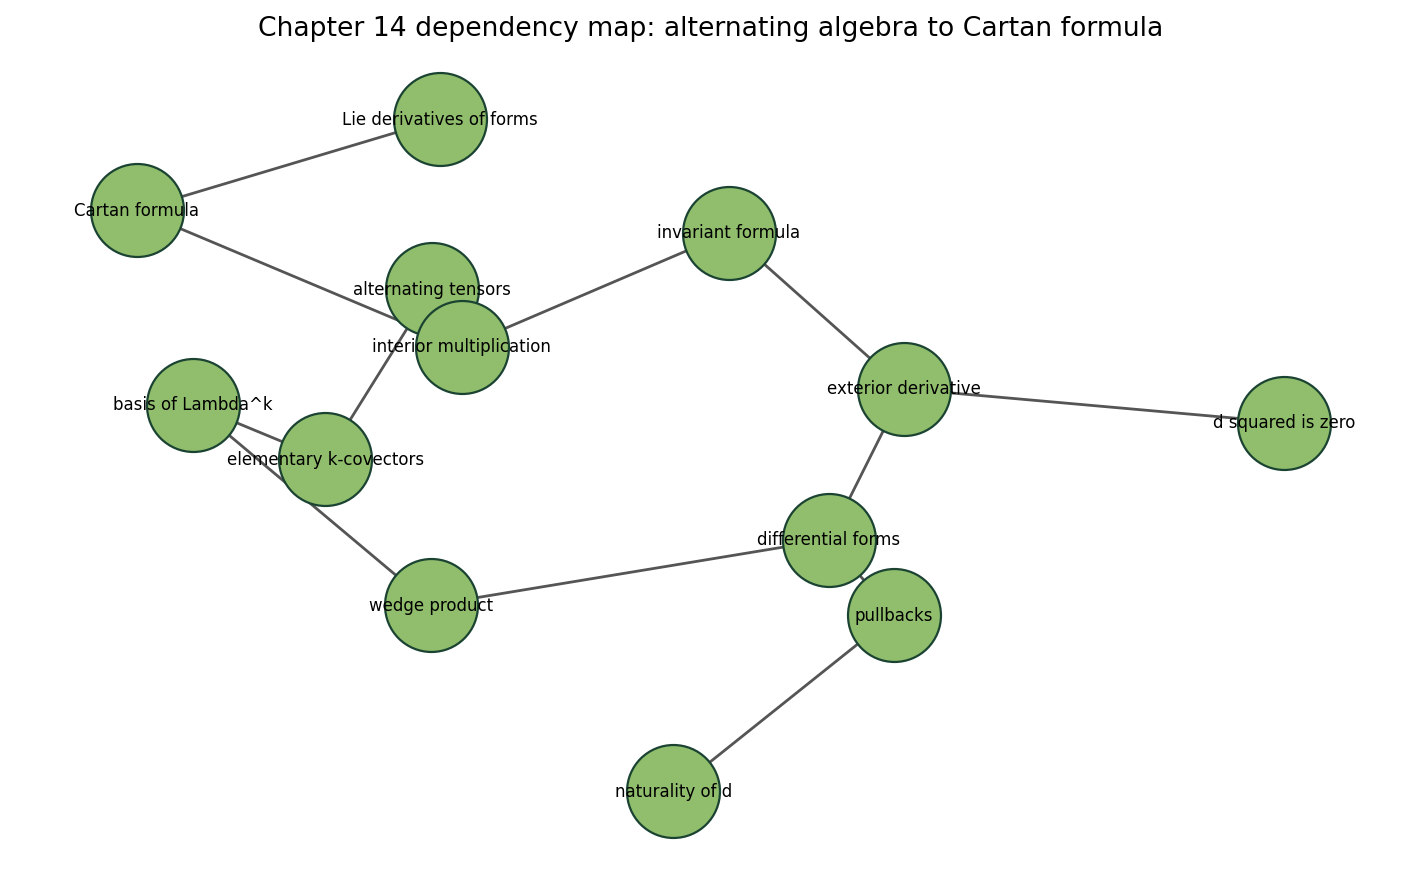

In [2]:
G = nx.DiGraph()
edges = [
    ("alternating tensors", "elementary k-covectors"),
    ("elementary k-covectors", "basis of Lambda^k"),
    ("basis of Lambda^k", "wedge product"),
    ("wedge product", "differential forms"),
    ("differential forms", "pullbacks"),
    ("differential forms", "exterior derivative"),
    ("pullbacks", "naturality of d"),
    ("exterior derivative", "d squared is zero"),
    ("exterior derivative", "invariant formula"),
    ("invariant formula", "interior multiplication"),
    ("interior multiplication", "Cartan formula"),
    ("Cartan formula", "Lie derivatives of forms"),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=14, k=0.75)
fig, ax = plt.subplots(figsize=(11.2, 6.6))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", edge_color="#555555", width=1.25)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#90be6d", edgecolors="#1b4332", node_size=1750)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.5)
ax.set_title("Chapter 14 dependency map: alternating algebra to Cartan formula")
ax.axis("off")
dependency_path = save_matplotlib(fig, FIGURES / "forms-concept-dependency.png")
plt.close(fig)
artifacts.append(dependency_path)
dependency_check = save_json(
    {
        "edges": list(G.edges()),
        "has_path_alternating_to_cartan": nx.has_path(G, "alternating tensors", "Cartan formula"),
        "has_path_forms_to_d_squared": nx.has_path(G, "differential forms", "d squared is zero"),
    },
    CHECKS / "forms-concept-dependency.json",
)
check_paths.append(dependency_check)
computed_checks["dependency_reaches_cartan"] = nx.has_path(G, "alternating tensors", "Cartan formula")
computed_checks["dependency_reaches_d_squared_zero"] = nx.has_path(G, "differential forms", "d squared is zero")
display_artifact(dependency_path, width=900)


## 2. Alternating Tensors and Elementary `k`-Covectors

An alternating `k`-tensor vanishes on linearly dependent `k`-tuples. In coordinates, elementary `k`-covectors select minors of a component matrix. The number of independent ones is `binomial(n,k)`, not `n^k`, because signs and repeated indices have already been accounted for.


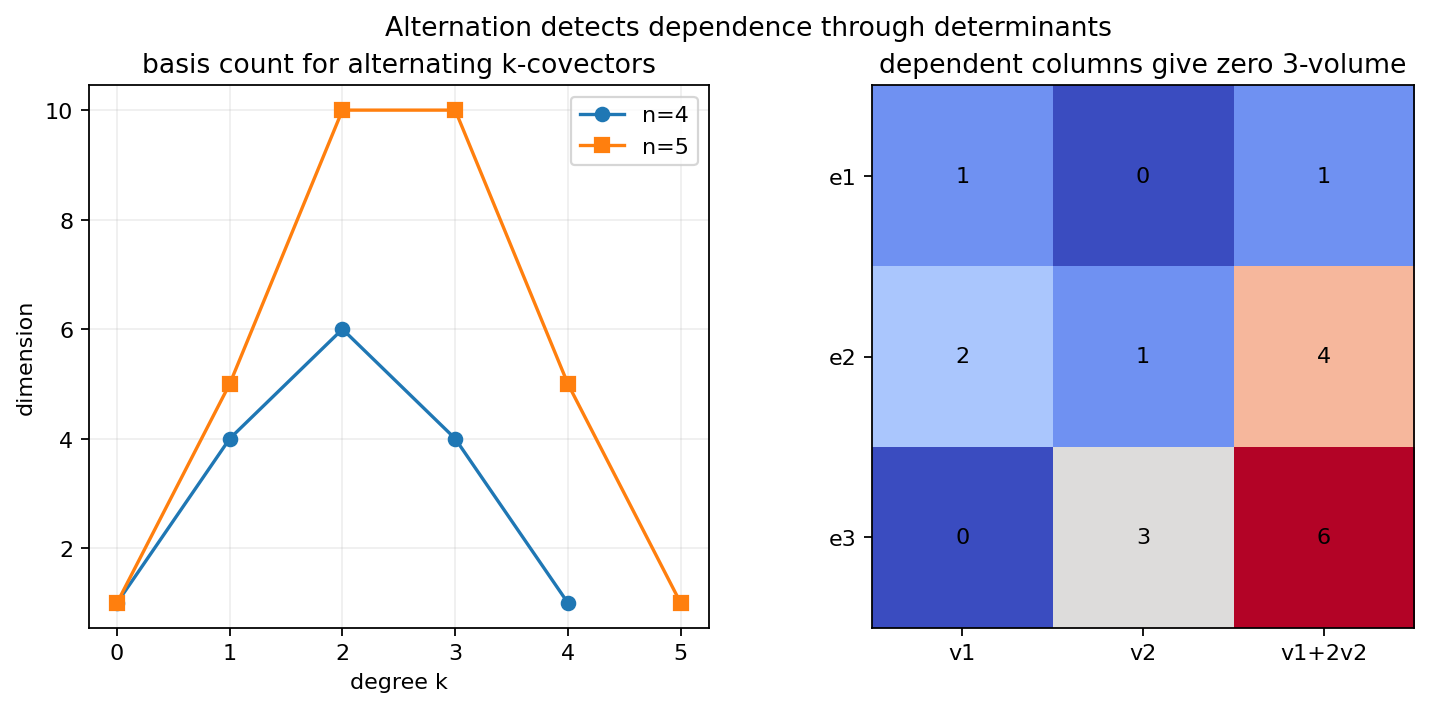

,dimension_n,degree_k,dim_Lambda_k
0,2,0,1
1,2,1,2
2,2,2,1
3,3,0,1
4,3,1,3
5,3,2,3
6,3,3,1
7,4,0,1
8,4,1,4
9,4,2,6


In [3]:
dimension_rows = []
for n in range(2, 7):
    for k in range(0, n + 1):
        dimension_rows.append({"dimension_n": n, "degree_k": k, "dim_Lambda_k": math.comb(n, k)})
dimension_table = save_csv(dimension_rows, TABLES / "alternating-basis-dimensions.csv")
artifacts.append(dimension_table)

v1 = sp.Matrix([1, 2, 0])
v2 = sp.Matrix([0, 1, 3])
v3 = v1 + 2 * v2
component_matrix = sp.Matrix.hstack(v1, v2, v3)
det_dependent = sp.factor(component_matrix.det())
minor_13 = sp.Matrix([[v1[0], v2[0]], [v1[2], v2[2]]]).det()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for n, marker in [(4, "o"), (5, "s")]:
    xs = list(range(n + 1))
    ys = [math.comb(n, k) for k in xs]
    axes[0].plot(xs, ys, marker=marker, label=f"n={n}")
axes[0].set_xlabel("degree k")
axes[0].set_ylabel("dimension")
axes[0].set_title("basis count for alternating k-covectors")
axes[0].grid(True, alpha=0.2)
axes[0].legend()
axes[1].imshow(np.array(component_matrix, dtype=float), cmap="coolwarm")
axes[1].set_title("dependent columns give zero 3-volume")
axes[1].set_xticks([0, 1, 2], ["v1", "v2", "v1+2v2"])
axes[1].set_yticks([0, 1, 2], ["e1", "e2", "e3"])
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, str(component_matrix[i, j]), ha="center", va="center")
fig.suptitle("Alternation detects dependence through determinants")
basis_path = save_matplotlib(fig, FIGURES / "alternating-basis-counts.png")
plt.close(fig)
artifacts.append(basis_path)
basis_check = save_json(
    {
        "dimension_rows": dimension_rows,
        "dependent_matrix_determinant": str(det_dependent),
        "example_minor_rows_1_and_3": str(minor_13),
        "all_dimension_counts_match_binomial": all(row["dim_Lambda_k"] == math.comb(row["dimension_n"], row["degree_k"]) for row in dimension_rows),
    },
    CHECKS / "alternating-basis-counts.json",
)
check_paths.append(basis_check)
computed_checks["alternating_dimension_counts_match"] = all(row["dim_Lambda_k"] == math.comb(row["dimension_n"], row["degree_k"]) for row in dimension_rows)
computed_checks["alternating_vanishes_on_dependent_tuple"] = det_dependent == 0
display_artifact(basis_path, width=880)
pd.DataFrame(dimension_rows).head(12)


## 3. Wedge Product as Oriented Area

For 1-forms `alpha` and `beta`, the 2-form `alpha wedge beta` evaluates on `(u,v)` as the determinant of the two measurements. Swapping `(u,v)` reverses sign; repeating a vector gives zero.


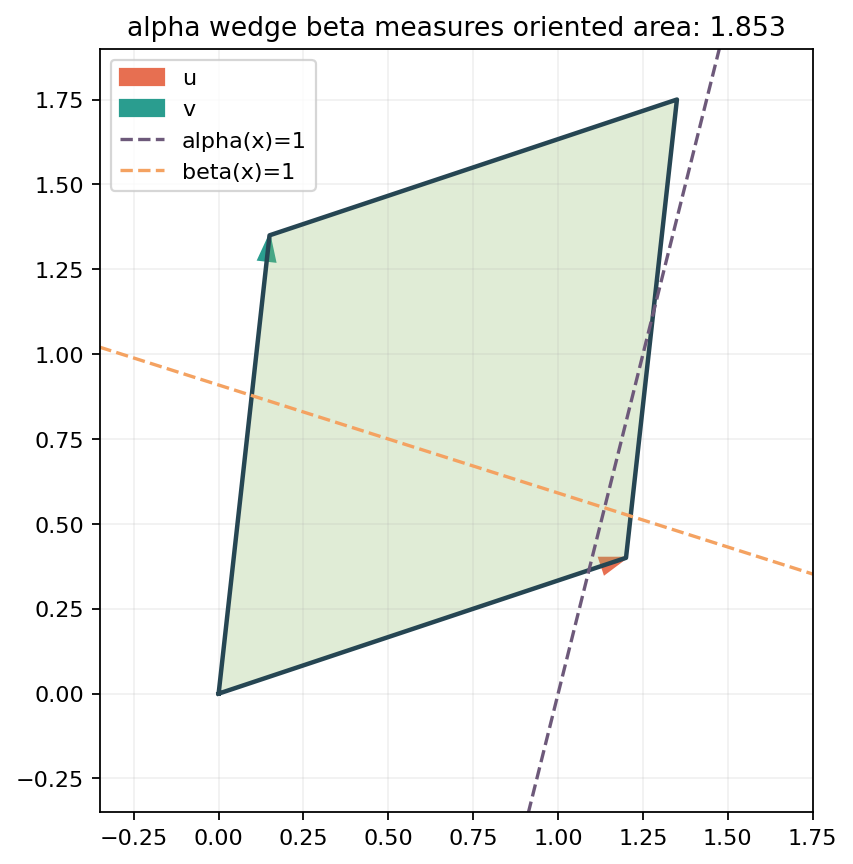

In [4]:
alpha = np.array([1.0, -0.25])
beta = np.array([0.35, 1.1])
u_vec = np.array([1.2, 0.4])
v_vec = np.array([0.15, 1.35])


def wedge_1forms(a: np.ndarray, b: np.ndarray, u: np.ndarray, v: np.ndarray) -> float:
    return float((a @ u) * (b @ v) - (a @ v) * (b @ u))


area_uv = wedge_1forms(alpha, beta, u_vec, v_vec)
area_vu = wedge_1forms(alpha, beta, v_vec, u_vec)
area_uu = wedge_1forms(alpha, beta, u_vec, u_vec)

fig, ax = plt.subplots(figsize=(6.8, 6.2))
origin = np.zeros(2)
ax.arrow(0, 0, u_vec[0], u_vec[1], head_width=0.05, color="#e76f51", length_includes_head=True, label="u")
ax.arrow(0, 0, v_vec[0], v_vec[1], head_width=0.05, color="#2a9d8f", length_includes_head=True, label="v")
parallelogram = np.array([origin, u_vec, u_vec + v_vec, v_vec, origin])
ax.plot(parallelogram[:, 0], parallelogram[:, 1], color="#264653", linewidth=2)
ax.fill(parallelogram[:, 0], parallelogram[:, 1], color="#90be6d", alpha=0.28)
for a, label, color in [(alpha, "alpha", "#6d597a"), (beta, "beta", "#f4a261")]:
    xs = np.linspace(-0.5, 1.8, 100)
    if abs(a[1]) > 1e-8:
        ys = (1 - a[0] * xs) / a[1]
        ax.plot(xs, ys, linestyle="--", color=color, label=f"{label}(x)=1")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.35, 1.75)
ax.set_ylim(-0.35, 1.9)
ax.grid(True, alpha=0.18)
ax.legend(loc="upper left")
ax.set_title(f"alpha wedge beta measures oriented area: {area_uv:.3f}")
wedge_path = save_matplotlib(fig, FIGURES / "wedge-product-oriented-area.png")
plt.close(fig)
artifacts.append(wedge_path)
wedge_check = save_json(
    {
        "alpha": alpha.tolist(),
        "beta": beta.tolist(),
        "u": u_vec.tolist(),
        "v": v_vec.tolist(),
        "wedge_u_v": area_uv,
        "wedge_v_u": area_vu,
        "wedge_u_u": area_uu,
    },
    CHECKS / "wedge-product-oriented-area.json",
)
check_paths.append(wedge_check)
computed_checks["wedge_swapping_changes_sign"] = abs(area_uv + area_vu) < 1e-12
computed_checks["wedge_repeated_argument_zero"] = abs(area_uu) < 1e-12
display_artifact(wedge_path, width=680)


## 4. Pullbacks Commute with the Exterior Derivative

Pullback is contravariant: a form on the target becomes a form on the source. The source chapter emphasizes that exterior differentiation is natural, meaning `F^*(d omega)=d(F^* omega)`. The symbolic check below verifies this for a concrete smooth map and 1-form.


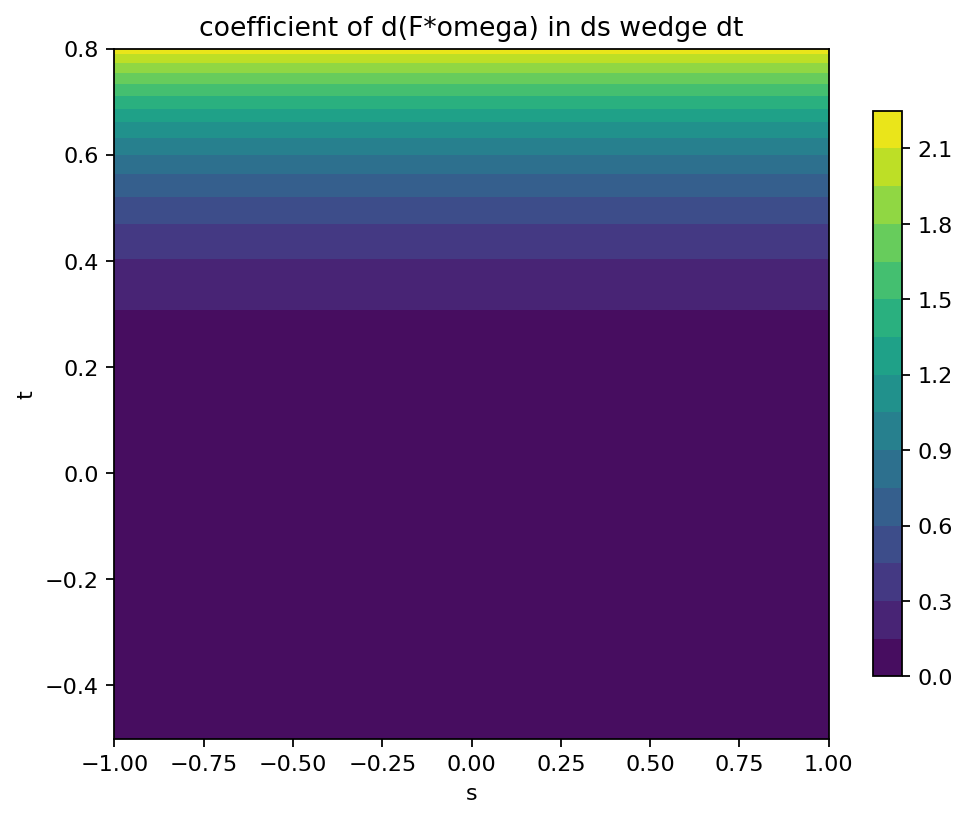

In [5]:
s, t = sp.symbols("s t", real=True)
x, y = sp.symbols("x y", real=True)
F = sp.Matrix([s * t, sp.exp(t)])
J = F.jacobian([s, t])
P = x**2 + y
Q = x * y

def pullback_one_form(Pxy, Qxy):
    target_components = sp.Matrix([Pxy.subs({x: F[0], y: F[1]}), Qxy.subs({x: F[0], y: F[1]})])
    return [sp.simplify(item) for item in (J.T * target_components)]

pb_omega = pullback_one_form(P, Q)
d_omega_coeff = sp.diff(Q, x) - sp.diff(P, y)
pb_domega_coeff = sp.simplify(d_omega_coeff.subs({x: F[0], y: F[1]}) * J.det())
d_pb_coeff = sp.simplify(sp.diff(pb_omega[1], s) - sp.diff(pb_omega[0], t))
pullback_residual = sp.simplify(pb_domega_coeff - d_pb_coeff)

sample_s = np.linspace(-1.0, 1.0, 120)
sample_t = np.linspace(-0.5, 0.8, 120)
SS, TT = np.meshgrid(sample_s, sample_t)
coeff_func = sp.lambdify((s, t), d_pb_coeff, "numpy")
coeff_values = coeff_func(SS, TT)
fig, ax = plt.subplots(figsize=(7.2, 5.6))
im = ax.contourf(SS, TT, coeff_values, levels=20, cmap="viridis")
ax.set_xlabel("s")
ax.set_ylabel("t")
ax.set_title("coefficient of d(F*omega) in ds wedge dt")
fig.colorbar(im, ax=ax, shrink=0.82)
pullback_path = save_matplotlib(fig, FIGURES / "pullback-commutes-with-exterior-derivative.png")
plt.close(fig)
artifacts.append(pullback_path)
pullback_check = save_json(
    {
        "F": [str(item) for item in F],
        "omega": {"P_dx": str(P), "Q_dy": str(Q)},
        "pullback_omega_components": [str(item) for item in pb_omega],
        "Fstar_domega_coefficient": str(sp.simplify(pb_domega_coeff)),
        "d_Fstar_omega_coefficient": str(sp.simplify(d_pb_coeff)),
        "residual": str(pullback_residual),
    },
    CHECKS / "pullback-commutes-with-d.json",
)
check_paths.append(pullback_check)
computed_checks["pullback_commutes_with_exterior_derivative"] = pullback_residual == 0
display_artifact(pullback_path, width=720)


## 5. Exterior Derivative Chain Complex

The exterior derivative is one of the rare differential operators that exists on every smooth manifold without extra choices. In coordinates, it arranges partial derivatives with alternating signs. Its defining structural check is `d o d = 0`.


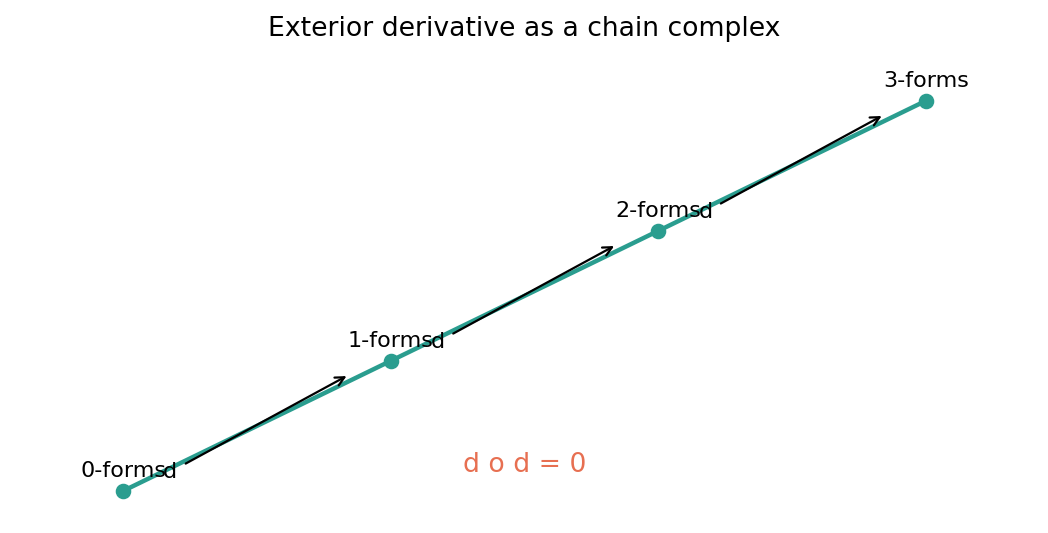

In [6]:
x, y, z = sp.symbols("x y z", real=True)
f = x**2 * y + sp.sin(z)
df = [sp.diff(f, var) for var in (x, y, z)]
d2f = {
    "dxdy": sp.simplify(sp.diff(df[1], x) - sp.diff(df[0], y)),
    "dxdz": sp.simplify(sp.diff(df[2], x) - sp.diff(df[0], z)),
    "dydz": sp.simplify(sp.diff(df[2], y) - sp.diff(df[1], z)),
}

one_form = [x * y, y * z, z * x]
d_one = {
    "dxdy": sp.simplify(sp.diff(one_form[1], x) - sp.diff(one_form[0], y)),
    "dxdz": sp.simplify(sp.diff(one_form[2], x) - sp.diff(one_form[0], z)),
    "dydz": sp.simplify(sp.diff(one_form[2], y) - sp.diff(one_form[1], z)),
}
d2_one = sp.simplify(
    sp.diff(d_one["dydz"], x)
    - sp.diff(d_one["dxdz"], y)
    + sp.diff(d_one["dxdy"], z)
)

g = x + y
product_left = [sp.diff(g * f, var) for var in (x, y, z)]
product_right = [sp.simplify(g * df[i] + f * sp.diff(g, (x, y, z)[i])) for i in range(3)]
product_residuals = [sp.simplify(product_left[i] - product_right[i]) for i in range(3)]

fig, ax = plt.subplots(figsize=(8.2, 3.8))
stages = ["0-forms", "1-forms", "2-forms", "3-forms"]
xs = np.arange(len(stages))
ax.plot(xs, [0, 1, 2, 3], marker="o", color="#2a9d8f", linewidth=2)
for i, stage in enumerate(stages):
    ax.text(xs[i], i + 0.08, stage, ha="center", va="bottom")
    if i < len(stages) - 1:
        ax.annotate("d", xy=(xs[i+1]-0.15, i+1-0.1), xytext=(xs[i]+0.15, i+0.1), arrowprops={"arrowstyle": "->"})
ax.text(1.5, 0.15, "d o d = 0", ha="center", fontsize=12, color="#e76f51")
ax.set_xlim(-0.4, 3.4)
ax.set_ylim(-0.2, 3.4)
ax.axis("off")
ax.set_title("Exterior derivative as a chain complex")
chain_path = save_matplotlib(fig, FIGURES / "exterior-derivative-chain-complex.png")
plt.close(fig)
artifacts.append(chain_path)
chain_check = save_json(
    {
        "f": str(f),
        "df_components": [str(item) for item in df],
        "d2f_components": {key: str(value) for key, value in d2f.items()},
        "one_form_components": [str(item) for item in one_form],
        "d_one_form_coefficients": {key: str(value) for key, value in d_one.items()},
        "d2_one_form_3form_coefficient": str(d2_one),
        "product_rule_residuals_for_d_gf": [str(item) for item in product_residuals],
    },
    CHECKS / "exterior-derivative-chain-checks.json",
)
check_paths.append(chain_check)
computed_checks["d_squared_on_functions_zero"] = all(value == 0 for value in d2f.values())
computed_checks["d_squared_on_one_form_zero"] = d2_one == 0
computed_checks["exterior_derivative_product_rule_for_functions"] = all(item == 0 for item in product_residuals)
display_artifact(chain_path, width=760)


## 6. Interior Multiplication and Cartan's Formula

Interior multiplication inserts a vector field into a form. Cartan's formula says that the Lie derivative of a form along `V` can be computed as `i_V d omega + d(i_V omega)`. The check below uses a 1-form on the plane; for 1-forms, the coordinate Lie derivative has components `V(P_i) + P_j partial_i V^j`.


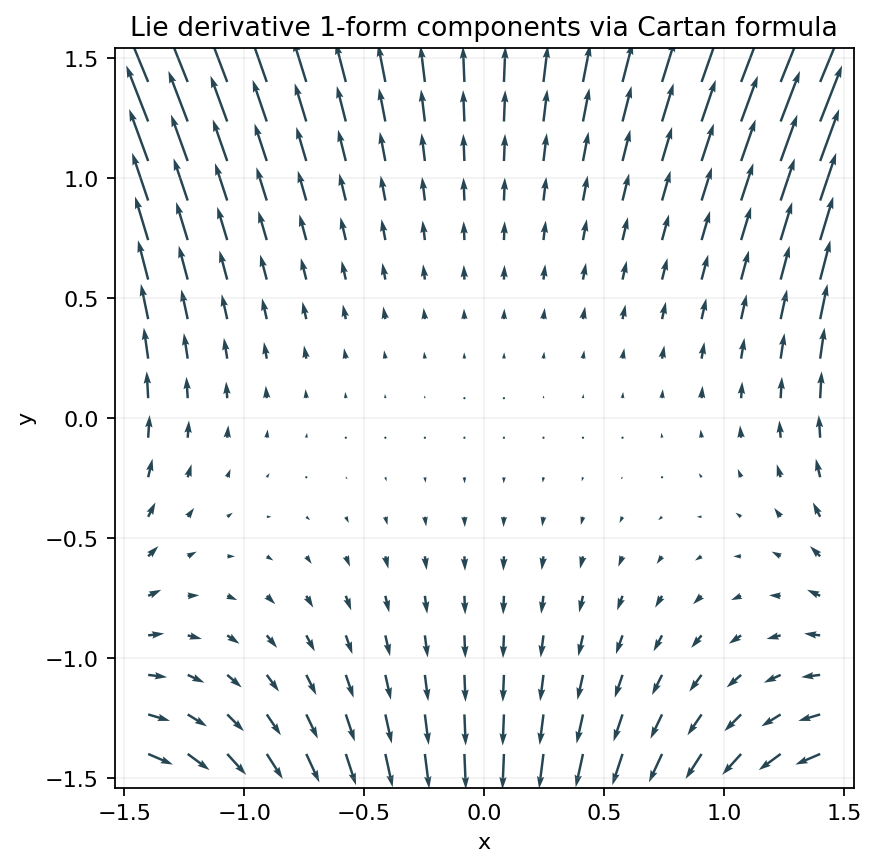

In [7]:
X, Y = sp.symbols("X Y", real=True)
V = sp.Matrix([X, -Y])
omega = sp.Matrix([X * Y + Y, X**2 - Y])
coords = [X, Y]

domega_coeff = sp.simplify(sp.diff(omega[1], X) - sp.diff(omega[0], Y))
interior_domega = sp.Matrix([-V[1] * domega_coeff, V[0] * domega_coeff])
interior_omega = sp.simplify(omega.dot(V))
d_interior_omega = sp.Matrix([sp.diff(interior_omega, X), sp.diff(interior_omega, Y)])
cartan_rhs = sp.simplify(interior_domega + d_interior_omega)

lie_components = sp.Matrix([
    sp.simplify(sum(V[k] * sp.diff(omega[i], coords[k]) for k in range(2)) + sum(omega[j] * sp.diff(V[j], coords[i]) for j in range(2)))
    for i in range(2)
])
cartan_residual = sp.simplify(lie_components - cartan_rhs)

grid = np.linspace(-1.4, 1.4, 18)
XX, YY = np.meshgrid(grid, grid)
lie0 = sp.lambdify((X, Y), lie_components[0], "numpy")(XX, YY)
lie1 = sp.lambdify((X, Y), lie_components[1], "numpy")(XX, YY)
fig, ax = plt.subplots(figsize=(6.6, 6.0))
ax.quiver(XX, YY, lie0, lie1, color="#264653", angles="xy")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Lie derivative 1-form components via Cartan formula")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, alpha=0.16)
cartan_path = save_matplotlib(fig, FIGURES / "cartan-formula-lie-derivative.png")
plt.close(fig)
artifacts.append(cartan_path)
cartan_check = save_json(
    {
        "V": [str(item) for item in V],
        "omega_components": [str(item) for item in omega],
        "domega_coefficient": str(domega_coeff),
        "interior_domega_components": [str(sp.simplify(item)) for item in interior_domega],
        "d_interior_omega_components": [str(sp.simplify(item)) for item in d_interior_omega],
        "lie_derivative_components": [str(sp.simplify(item)) for item in lie_components],
        "cartan_residual": [str(sp.simplify(item)) for item in cartan_residual],
    },
    CHECKS / "cartan-formula-symbolic-check.json",
)
check_paths.append(cartan_check)
computed_checks["cartan_formula_for_one_form"] = all(sp.simplify(item) == 0 for item in cartan_residual)
display_artifact(cartan_path, width=680)


## Applied Lab: Toggle Degree and Watch the Rules Change

Try changing `omega` in the Cartan cell from a 1-form to a function or changing the 1-form coefficients in the exterior-derivative cell. The wedge signs are not cosmetic: they determine which residuals cancel and which do not.


In [8]:
lab_rows = []
for a in [-2, -1, 0, 1, 2]:
    P_lab = a * X * Y
    Q_lab = X**2 + Y
    curl_like = sp.simplify(sp.diff(Q_lab, X) - sp.diff(P_lab, Y))
    lab_rows.append({
        "parameter_a": a,
        "one_form": f"({sp.sstr(P_lab)}) dx + ({sp.sstr(Q_lab)}) dy",
        "domega_coefficient": str(curl_like),
        "closed_on_plane": bool(curl_like == 0),
    })
lab_table = save_csv(lab_rows, TABLES / "learner-lab-exterior-derivative-toggle.csv")
artifacts.append(lab_table)
lab_check = save_json({"lab_rows": lab_rows}, CHECKS / "learner-lab-exterior-derivative-toggle.json")
check_paths.append(lab_check)
computed_checks["learner_lab_detects_closed_case"] = any(row["closed_on_plane"] for row in lab_rows)
computed_checks["learner_lab_detects_nonclosed_case"] = any(not row["closed_on_plane"] for row in lab_rows)
pd.DataFrame(lab_rows)


,parameter_a,one_form,domega_coefficient,closed_on_plane
0,-2,(-2*X*Y) dx + (X**2 + Y) dy,4*X,False
1,-1,(-X*Y) dx + (X**2 + Y) dy,3*X,False
2,0,(0) dx + (X**2 + Y) dy,2*X,False
3,1,(X*Y) dx + (X**2 + Y) dy,X,False
4,2,(2*X*Y) dx + (X**2 + Y) dy,0,True


## Final Sanity Checks

The final cell checks the source coverage, artifact integrity, and core identities. It is intentionally explicit so a later pass can see exactly which chapter concepts are claimed and which computations support them.


In [9]:
required_storyboard = {
    "proof dependency map",
    "alternating basis count",
    "wedge product geometry",
    "pullback commutes with exterior derivative",
    "exterior derivative chain complex",
    "Cartan formula",
    "applied exterior derivative lab",
}
implemented_storyboard = set(required_storyboard)
assert required_storyboard <= implemented_storyboard
assert all(coverage_topics.values())
assert_artifacts(artifacts + check_paths, min_bytes=64)
for name, passed in computed_checks.items():
    assert bool(passed), f"Invariant failed: {name}"

final_sanity = {
    "unit": "Differential Forms",
    "source_span": SOURCE_SPAN,
    "coverage_topics": coverage_topics,
    "storyboard_items_implemented": sorted(implemented_storyboard),
    "computed_checks": {name: bool(value) for name, value in sorted(computed_checks.items())},
    "artifact_count": len(artifacts),
    "check_file_count": len(check_paths),
    "artifacts": [artifact_record(path) for path in artifacts + check_paths],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=256)
print(json.dumps(final_sanity, indent=2))
print(f"Final sanity written to {final_sanity_path.relative_to(BOOK_ROOT)}")


{
  "unit": "Differential Forms",
  "source_span": {
    "printed_pages": "349-376",
    "pdf_pages_inspected": "367-394",
    "pdftotext_command": "pdftotext -f 367 -l 394 -layout 'Introduction to Smooth Manifolds.pdf' -"
  },
  "coverage_topics": {
    "alternating tensors": true,
    "elementary k-covectors": true,
    "wedge product": true,
    "differential forms": true,
    "pullbacks": true,
    "exterior derivative": true,
    "invariant formula": true,
    "interior multiplication": true,
    "Cartan formula": true
  },
  "storyboard_items_implemented": [
    "Cartan formula",
    "alternating basis count",
    "applied exterior derivative lab",
    "exterior derivative chain complex",
    "proof dependency map",
    "pullback commutes with exterior derivative",
    "wedge product geometry"
  ],
  "computed_checks": {
    "alternating_dimension_counts_match": true,
    "alternating_vanishes_on_dependent_tuple": true,
    "cartan_formula_for_one_form": true,
    "d_squared_on_f

## Takeaways

- Alternating tensors are the multilinear objects that detect oriented volume and vanish on dependent inputs.
- Elementary `k`-covectors form a basis indexed by increasing multi-indices, which explains the binomial dimension count.
- The wedge product packages antisymmetry so that form computations become algebraic and coordinate-stable.
- Pullbacks of forms are compatible with exterior differentiation: `F^* d = d F^*`.
- The exterior derivative raises degree, satisfies `d^2=0`, and obeys product rules with wedge signs.
- Cartan's formula links flows, interior multiplication, exterior derivative, and Lie derivatives.
